# The EWMA Control Chart
### STAT 7110 — Quality Control
**Dr. Austin R. Brown**  
*Kennesaw State University*


In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "abrown9008"

## Set web address to forked repository (change to your own):

#repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

#if(!dir.exists("STAT-7110-Quality-Control")) {
#  system(paste0("git clone ", repo_address))
#} else {
#  print("Repository already cloned to Colab.")
#}

## Set working drive to today's lecture:

#setwd("Slides//Week-5-EWMA")

## Recap: Why We Needed More Than the Shewhart Chart

- Last week we introduced the **CUSUM** chart to address a key weakness of the Shewhart $\bar{X}$ chart: its insensitivity to small shifts ($\leq 2\sigma$) in the process mean, and its inefficient use of information across the whole sequence of points.

- However, the CUSUM chart is not without its own limitations: it is more complex to implement and interpret than the Shewhart $\bar{X}$ chart, and it may be less evident how to set the control limits $H$ and $K$.

- So how do we take the advantages of the CUSUM chart and combine them with the simplicity of the Shewhart $\bar{X}$ chart? This week, we introduce the **Exponentially Weighted Moving Average (EWMA)** chart.

## The EWMA Chart

- The Exponentially Weighted Moving Average (EWMA) chart was proposed by [Roberts (1959)](https://www.scirp.org/reference/referencespapers?referenceid=1374838).

- The EWMA chart is similar to the CUSUM chart in that it is designed to detect small shifts in the process mean and also utilizes information from the entire sequence of points.

- However, the EWMA chart is simpler to implement and interpret than the CUSUM chart.

- Unlike the CUSUM, where the plotting statistic is a function of the deviations away from target, the EWMA control chart "weights" the observations to provide a sort of moving average of the observations. (Note: EWMA can also be used as a method for predicting time series values.)

- This may be advantageous as far as interpretability is concerned, as the plotting statistic is a function of the observed values rather than the observed deviances.

## Foundations of the EWMA Chart

- Let's say we take a random sample ($n \geq 1$) and we calculate a sample mean (or the individual value in the case where $n=1$), and we'll call this value $x_i$.

- The plotting statistic for the EWMA control chart is defined as:

$$ z_i = \lambda x_i + (1-\lambda)z_{i-1} $$

- where $0 < \lambda \leq 1$ and $z_{0} = \mu_0$. With some rearranging, we can see that $z_i$ is the weighted average of all previously observed $x_i$'s.

$$ z_i = \lambda\sum_{j=0}^{i-1}(1-\lambda)^{j}x_{i-j} + (1-\lambda)^iz_0 $$

- Then, to create control limits, we need to know what the mean of $z_i$ is as well as the variance.

## The EWMA Chart — The Mean

$$ E[z_i] = E\bigg[\lambda\sum_{j=0}^{i-1}(1-\lambda)^{j}x_{i-j} + (1-\lambda)^iz_0\bigg] $$

$$ \implies \lambda\sum_{j=0}^{i-1}(1-\lambda)^{j}E[x_{i-j}] + (1-\lambda)^iE[z_0] $$

$$ \implies \lambda\sum_{j=0}^{i-1}(1-\lambda)^{j}\mu_0 + (1-\lambda)^i\mu_0 = \mu_0 $$

## The EWMA Chart — The Variance

$$ \sigma^2_{z_i} = Var[z_i] = Var\bigg[\lambda\sum_{j=0}^{i-1}(1-\lambda)^{j}x_{i-j} + (1-\lambda)^iz_0\bigg] $$

$$ \implies \lambda^2\sum_{j=0}^{i-1}(1-\lambda)^{2j}Var[x_{i-j}] $$

$$ \implies \sigma^2_{z_i} = \sigma^2_{x_i}\bigg(\frac{\lambda}{2-\lambda}\bigg)\big(1-(1-\lambda)^{2i}\big) $$

## The EWMA Chart — Control Limits

So we can construct our control limits as:

$$ UCL = \mu_0 + L\sqrt{\sigma^2_{x_i}\bigg(\frac{\lambda}{2-\lambda}\bigg)\big(1-(1-\lambda)^{2i}\big)} $$
$$ LCL = \mu_0 - L\sqrt{\sigma^2_{x_i}\bigg(\frac{\lambda}{2-\lambda}\bigg)\big(1-(1-\lambda)^{2i}\big)} $$

## The EWMA Chart — Steady-State Limits

Notice as $i\rightarrow\infty$:

$$ UCL = \mu_0 + L\sqrt{\sigma^2_{x_i}\bigg(\frac{\lambda}{2-\lambda}\bigg)} $$
$$ LCL = \mu_0 - L\sqrt{\sigma^2_{x_i}\bigg(\frac{\lambda}{2-\lambda}\bigg)} $$

- These limits are referred to as the "steady state" limits and are usually reached around $i = 20-30$. However, it is strongly recommended to use the exact limits for smaller values of $i$, as this will avoid issues associated with ARL.

## Choosing $L$ and $\lambda$

- General guidance on choosing a value of $\lambda$ is that if you want the chart to be more sensitive to smaller shifts, use a smaller value of $\lambda$, and vice versa.

- We can use $L=3$, as in a Shewhart-style chart, and that works pretty well for $ARL_0 \approx 500$. More exact values were given by [Lucas and Saccucci (1990)](https://www.tandfonline.com/doi/abs/10.1080/00401706.1990.10484583):

## Choosing $L$ and $\lambda$ — ARL Table

**ARL Values for the EWMA Control Chart**

| Shift in Mean (multiple of $\sigma$) | $L=3.054$, $\lambda=0.40$ | $L=2.998$, $\lambda=0.25$ | $L=2.962$, $\lambda=0.20$ | $L=2.814$, $\lambda=0.10$ | $L=2.615$, $\lambda=0.05$ |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 0 | 500 | 500 | 500 | 500 | 500 |
| 0.25 | 224 | 170 | 150 | 106 | 84.1 |
| 0.50 | 71.2 | 48.2 | 41.8 | 31.3 | 28.8 |
| 0.75 | 28.4 | 20.1 | 18.2 | 15.9 | 16.4 |
| 1.00 | 14.3 | 11.1 | 10.5 | 10.3 | 11.4 |
| 1.50 | 5.9 | 5.5 | 5.5 | 6.1 | 7.1 |
| 2.00 | 3.5 | 3.6 | 3.7 | 4.4 | 5.2 |
| 3.00 | 2.0 | 2.3 | 2.4 | 2.9 | 3.5 |


## The EWMA Chart in R

Let's revisit the soda bottles example from last week: we're filling soda bottles with a target fill of $\mu_0 = 16$ oz, sampling 5 bottles every hour for two days (48 hours). This time we'll use $\lambda = 0.20$ and $L = 2.962$.

In [2]:
## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘tidyverse’ was built under R version 4.5.3 
Warning message:
package ‘readxl’ was built under R version 4.5.3 


  __ _  ___ ___ 
 / _  |/ __/ __|  Quality Control Charts and 
| (_| | (_| (__   Statistical Process Control
 \__  |\___\___|
    |_|           version 2.7
Type 'citation("qcc")' for citing this R package in publications.


Warning message:
package ‘qcc’ was built under R version 4.5.3 


### Read in the Soda Bottles data

In [3]:
bottles <- read_xlsx("Soda Bottles.xlsx")

bottles |>
  glimpse()

Rows: 48
Columns: 5
$ `Bottle 1` <dbl> 15.78, 16.35, 16.03, 16.08, 16.10, 16.14, 16.09, 16.13, 16.10, 15.85, 15.98, 16.45, 16.08, 16.28, 16.00, 16.38, 16.23, 16.31, 15.98, 16.23, 15.75, 16.34, 1…
$ `Bottle 2` <dbl> 16.14, 16.05, 16.19, 16.31, 16.55, 16.22, 16.13, 16.18, 16.22, 15.92, 15.89, 16.35, 16.00, 16.15, 16.13, 16.12, 15.99, 16.41, 16.69, 16.50, 16.32, 16.13, 1…
$ `Bottle 3` <dbl> 15.94, 15.80, 16.08, 15.96, 16.06, 15.98, 15.92, 16.44, 16.32, 16.18, 16.35, 16.02, 16.69, 16.43, 15.92, 16.45, 16.31, 15.89, 15.95, 15.81, 15.97, 16.27, 1…
$ `Bottle 4` <dbl> 16.19, 16.12, 16.38, 16.13, 16.23, 16.24, 16.42, 16.32, 16.33, 16.01, 15.98, 16.14, 16.48, 15.83, 16.44, 16.29, 16.43, 16.08, 16.37, 16.53, 15.86, 16.11, 1…
$ `Bottle 5` <dbl> 16.53, 16.03, 16.29, 16.28, 16.26, 15.76, 16.40, 16.20, 16.27, 16.29, 15.86, 16.39, 16.21, 16.03, 16.31, 16.68, 16.13, 16.45, 16.39, 16.03, 15.99, 16.25, 1…


### Calculate the overall SD and set the target

In [4]:
sigma_hat <- sd.xbar(bottles,std.dev="UWAVE-SD")

mu0 <- 16

### Calculate the EWMA values manually before using the `qcc` function

In [5]:
lambda <- 0.20
L <- 2.962

EWMA_df <- tibble(Means = rowMeans(bottles))

### Calculate the EWMA values

In [6]:
ewma_values <- vector('double',length=nrow(EWMA_df))

for(i in 1:length(ewma_values)){
  
  if(i==1){
    
    ewma_values[i] <- lambda*EWMA_df$Means[i] + (1-lambda)*mu0
    
  } else {
    
    ewma_values[i] <- lambda*EWMA_df$Means[i] + (1-lambda)*ewma_values[i-1]
    
  }
  
}

### Calculate SD for EWMA

In [7]:
sd_ewma <- vector('double',length=nrow(EWMA_df))

for(i in 1:length(sd_ewma)){
  
  sd_ewma[i] <- sigma_hat^2/5*(lambda/(2-lambda))*(1-(1-lambda)^(2*i))
  
}

### Calculate the UCL and LCL

In [8]:
EWMA_df <- EWMA_df |>
  mutate(`EWMA Values` = ewma_values,
         Variance = sd_ewma,
         UCL = mu0 + L*sqrt(Variance),
         LCL = mu0 - L*sqrt(Variance)
  )

### Plot the manually-calculated EWMA chart

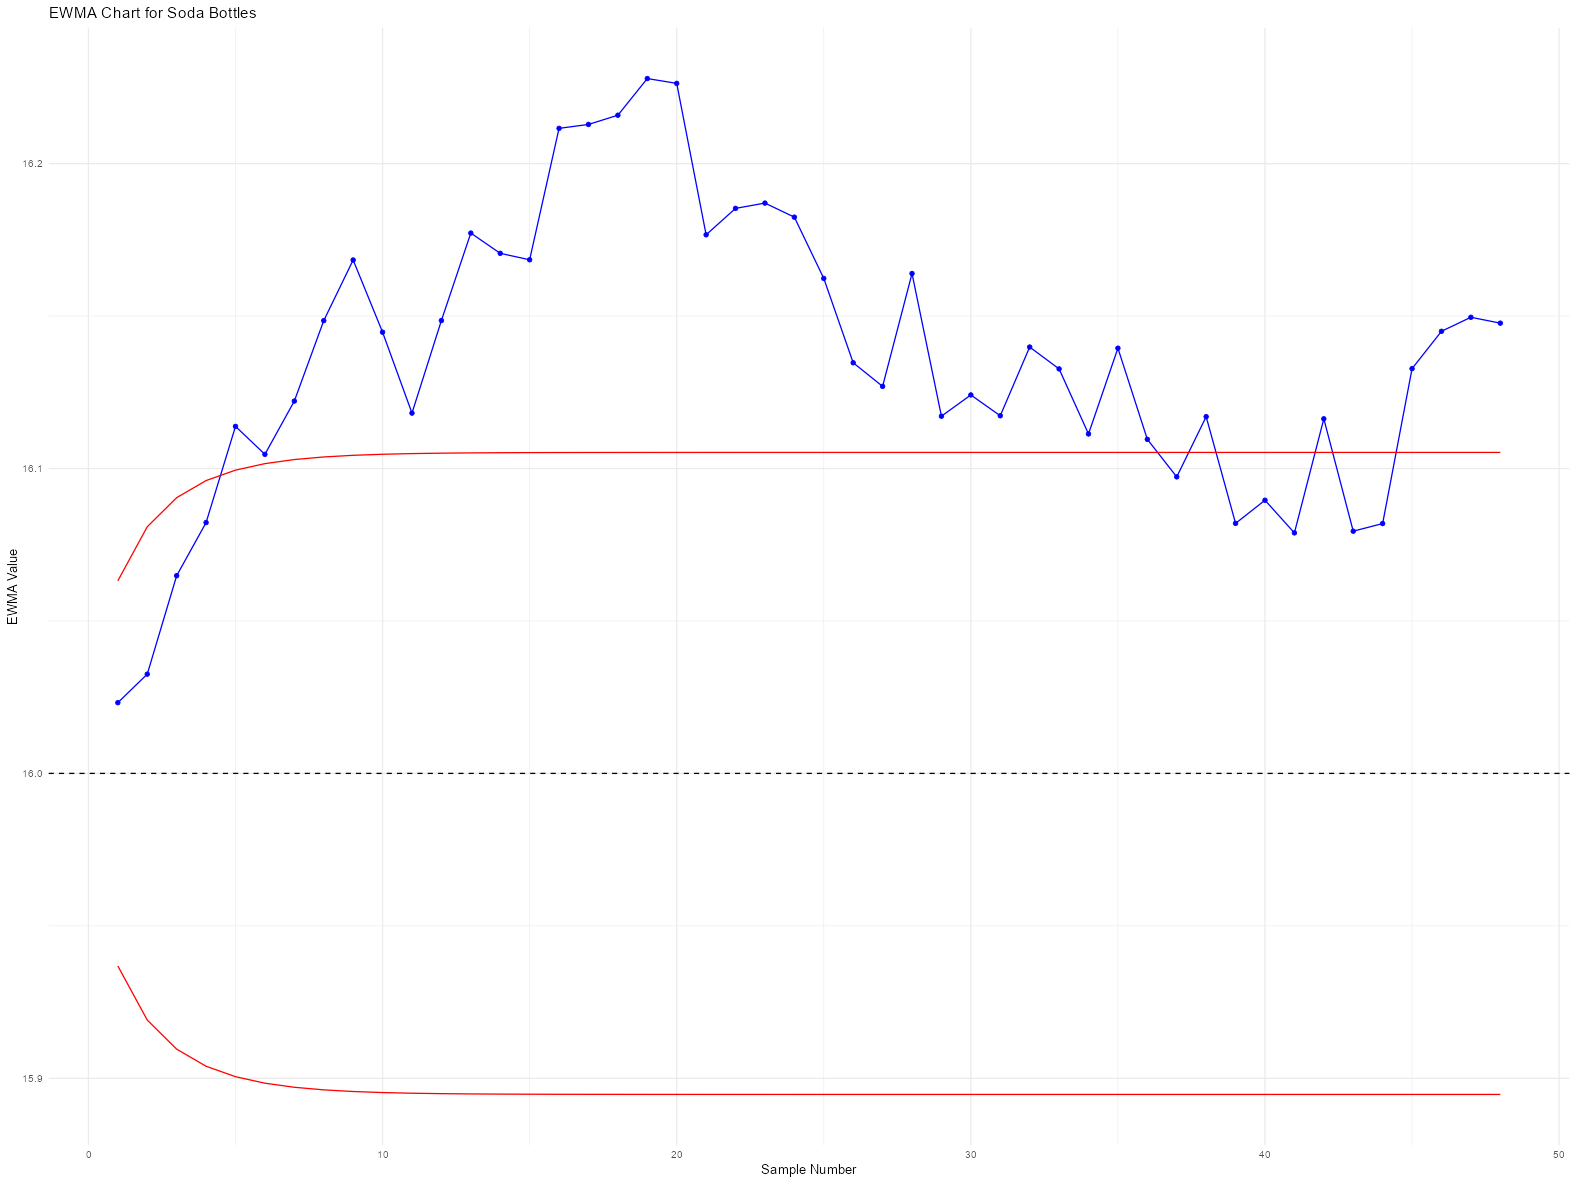

In [9]:
EWMA_df |>
  ggplot(aes(x=1:nrow(EWMA_df))) +
  geom_line(aes(y=`EWMA Values`),color="blue") +
  geom_point(aes(y=`EWMA Values`),color="blue",size=1.5) +
  geom_line(aes(y=UCL),color="red") +
  geom_line(aes(y=LCL),color="red") +
  geom_hline(yintercept=mu0,linetype="dashed") +
  labs(title="EWMA Chart for Soda Bottles",
       x="Sample Number",
       y="EWMA Value") +
  theme_minimal()

### Now let's do this using the `qcc` package

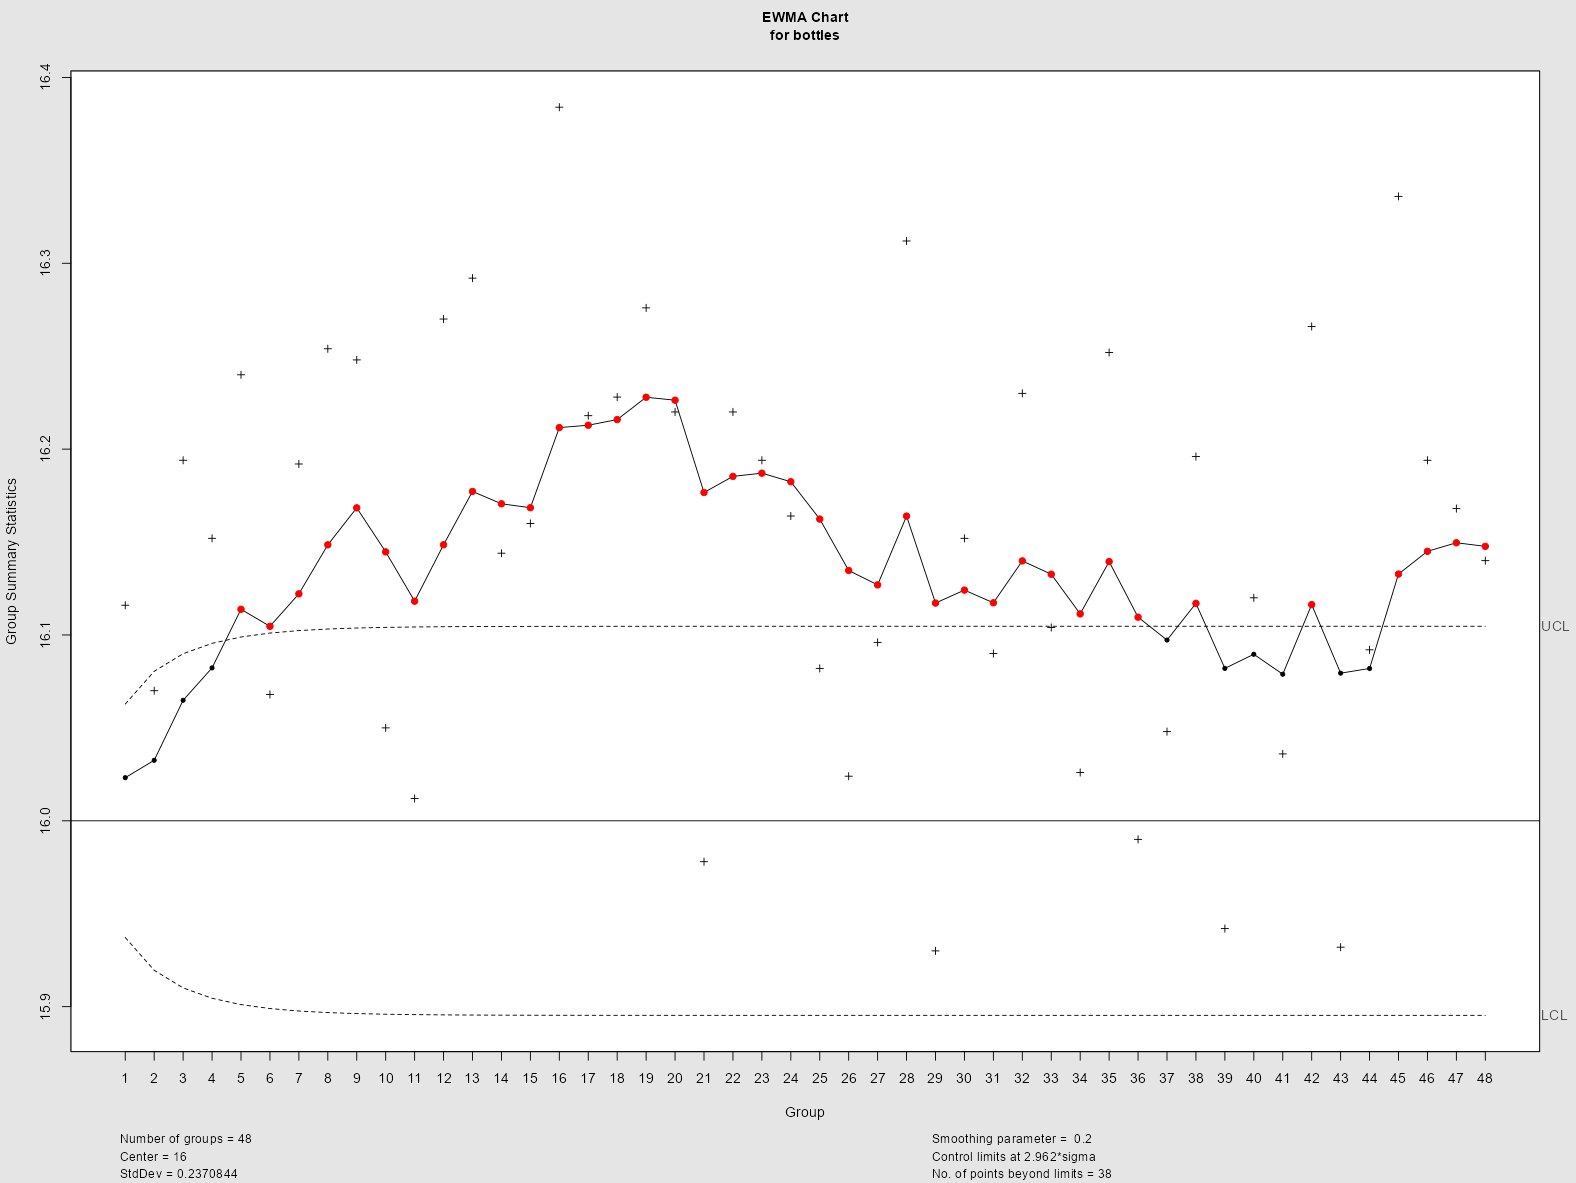

List of 15
 $ call      : language ewma(data = bottles, center = 16, lambda = 0.2, nsigmas = 2.962)
 $ type      : chr "ewma"
 $ data.name : chr "bottles"
 $ data      : num [1:48, 1:5] 15.8 16.4 16 16.1 16.1 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:48] 16.1 16.1 16.2 16.2 16.2 ...
  ..- attr(*, "names")= chr [1:48] "1" "2" "3" "4" ...
 $ sizes     : int [1:48] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 16
 $ std.dev   : num 0.237
 $ x         : int [1:48] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:48] 16 16 16.1 16.1 16.1 ...
  ..- attr(*, "names")= chr [1:48] "1" "2" "3" "4" ...
 $ sigma     : num [1:48] 0.0212 0.0272 0.0304 0.0322 0.0334 ...
 $ lambda    : num 0.2
 $ nsigmas   : num 2.96
 $ limits    : num [1:48, 1:2] 15.9 15.9 15.9 15.9 15.9 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int [1:38] 5 6 7 8 9 10 11 12 13 14 ...
  ..- attr(*, "names")= chr [1:38] "5" "6" "7" "8" ...
 - attr(*, "class")= chr "ewma.qcc"

In [10]:
ewma(bottles,center=16,lambda=0.2,nsigmas=2.962)

The main thing to point out here with both the CUSUM and EWMA charts is that `qcc` assumes you're working with the sample mean. So, you need to realize that $Var[\bar{X}] = Var[X]/n$.

## The EWMA Chart — Additional Example: Customer Hold Times

Let's say we want to monitor the amount of time customers spend on hold at a customer service support center. Suppose the target hold time is $\mu_0 = 10$ and $\sigma = 1$. Here, $n=1$, so we don't need to worry about the sample mean.

Data for the most recent 30 customers placed on hold are contained in this week's Excel spreadsheet.

In [11]:
customer_hold <- read_xlsx("EWMA Datasets.xlsx",sheet=1)

customer_hold |>
  glimpse()

Rows: 30
Columns: 2
$ Call <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30
$ Time <dbl> 9.45, 7.99, 9.29, 11.66, 12.16, 10.18, 8.04, 11.46, 9.20, 10.34, 9.03, 11.47, 10.51, 9.40, 10.08, 9.37, 10.62, 10.31, 8.52, 10.84, 10.90, 9.33, 12.29, 11.50, 10.…


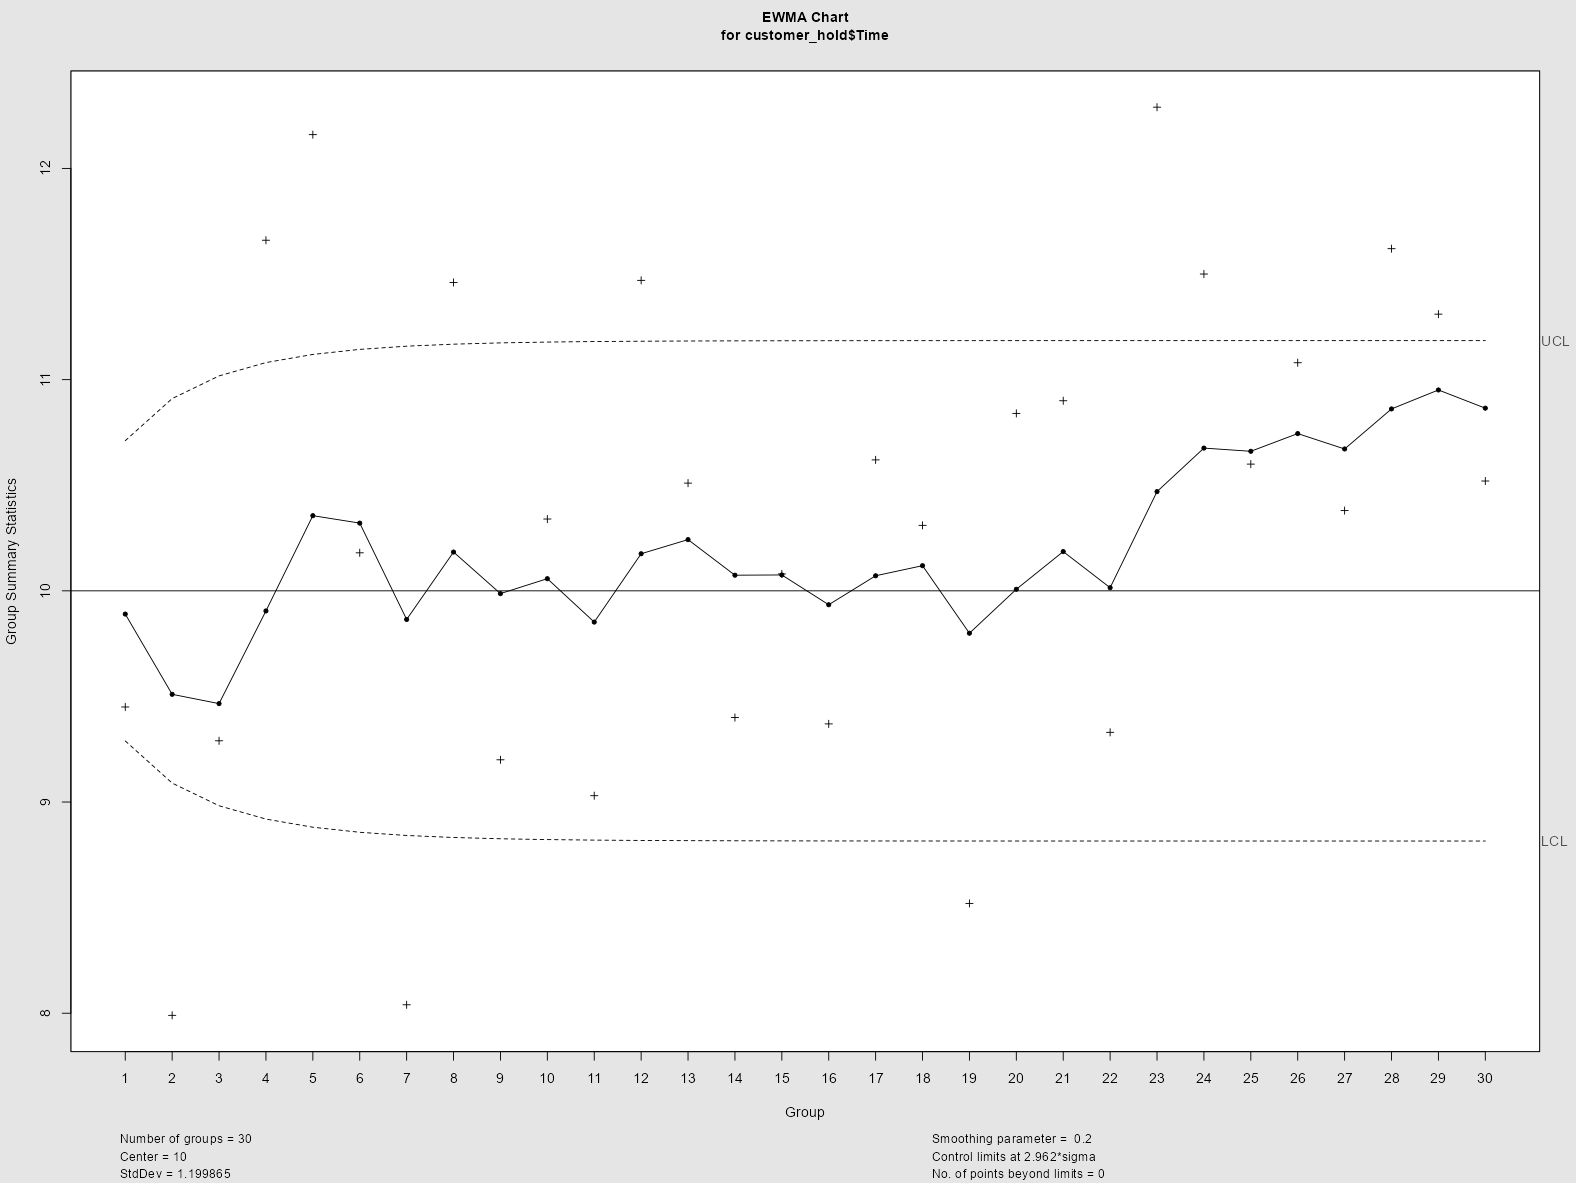

List of 15
 $ call      : language ewma(data = customer_hold$Time, center = 10, lambda = 0.2, nsigmas = 2.962, sigma = 1)
 $ type      : chr "ewma"
 $ data.name : chr "customer_hold$Time"
 $ data      : num [1:30, 1] 9.45 7.99 9.29 11.66 12.16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:30] 9.45 7.99 9.29 11.66 12.16 ...
  ..- attr(*, "names")= chr [1:30] "1" "2" "3" "4" ...
 $ sizes     : int [1:30] 1 1 1 1 1 1 1 1 1 1 ...
 $ center    : num 10
 $ std.dev   : num 1.2
 $ x         : int [1:30] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:30] 9.89 9.51 9.47 9.9 10.36 ...
  ..- attr(*, "names")= chr [1:30] "1" "2" "3" "4" ...
 $ sigma     : num [1:30] 0.24 0.307 0.344 0.365 0.378 ...
 $ lambda    : num 0.2
 $ nsigmas   : num 2.96
 $ limits    : num [1:30, 1:2] 9.29 9.09 8.98 8.92 8.88 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int(0) 
  ..- attr(*, "names")= chr(0) 
 - attr(*, "class")= chr "ewma.qcc"

In [12]:
ewma(customer_hold$Time,center=10,sigma = 1,lambda=0.2,nsigmas=2.962)

## The EWMA Chart — Phase I Considerations

- Now what about Phase I? As may be apparent, we don't really have distributional assumptions here. We mostly are just concerned about independence of observations and having a good estimate of the process mean and standard deviation.

- In the last example, we assumed the process mean and standard deviation were known. What if they're not? Don't we also need to ensure the process is in statistical control before moving on to Phase II analysis? Yes!

- Let's run through the Dunder-Mifflin example again. As a reminder, in order for our branch to be profitable, we need to maximize sales and control our operating costs. One such operating cost is the amount of fuel our warehouse delivery trucks use. In the second sheet of this week's class data, we have the past 24 months of fuel costs. Let's estimate the mean and standard deviation and see if the process is in control.

In [13]:
fuel_costs <- read_xlsx("EWMA Datasets.xlsx",sheet=2)

fuel_costs |>
  glimpse()

Rows: 24
Columns: 2
$ Cost  <dbl> 5525.27, 5084.35, 4021.17, 4923.73, 5254.42, 5404.45, 4843.34, 5317.60, 5432.54, 5296.34, 4879.27, 4686.64, 4562.50, 5058.12, 5400.74, 4474.92, 4178.80, 4696.50…
$ month <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12


### Estimate the process mean and standard deviation

In [14]:
## Estimate process mean ##

mu0 <- mean(fuel_costs$Cost)

## Estimate process standard deviation ##

sigma_hat <- sd(fuel_costs$Cost)

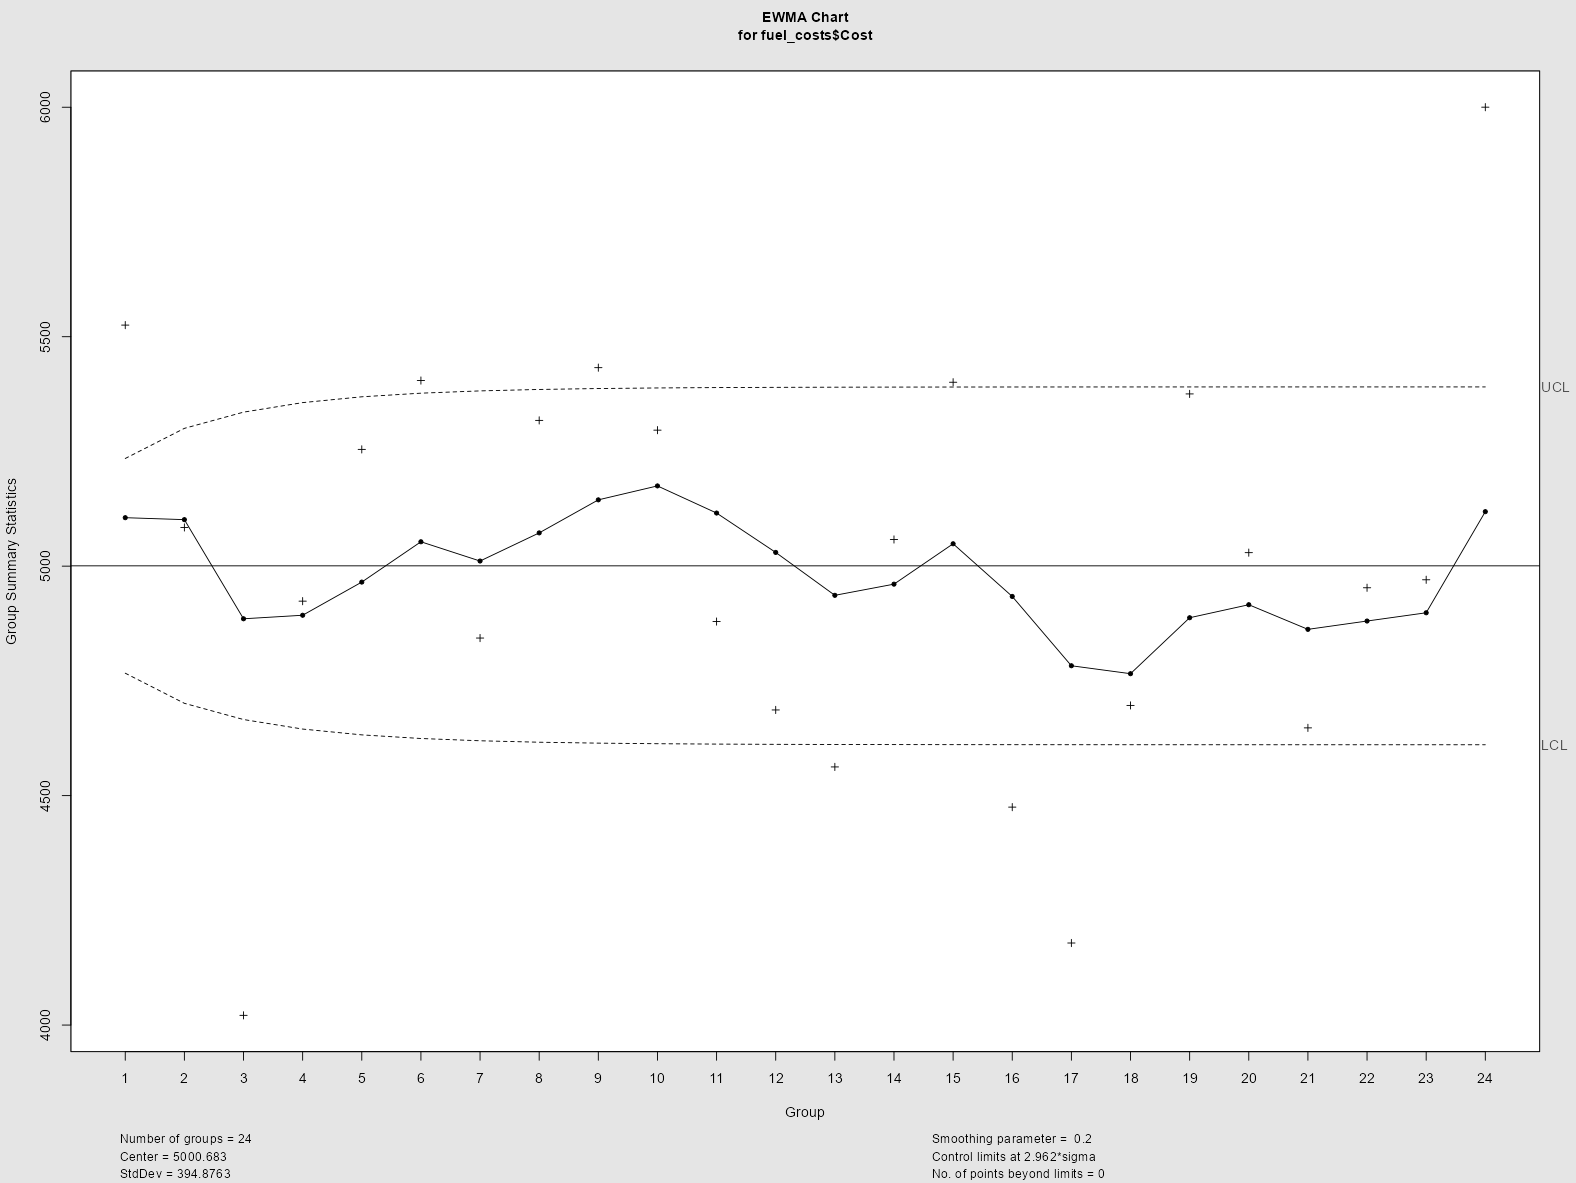

List of 15
 $ call      : language ewma(data = fuel_costs$Cost, center = mu0, lambda = 0.2, nsigmas = 2.962, sigma = sigma_hat)
 $ type      : chr "ewma"
 $ data.name : chr "fuel_costs$Cost"
 $ data      : num [1:24, 1] 5525 5084 4021 4924 5254 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:24] 5525 5084 4021 4924 5254 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sizes     : int [1:24] 1 1 1 1 1 1 1 1 1 1 ...
 $ center    : num 5001
 $ std.dev   : num 395
 $ x         : int [1:24] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:24] 5106 5101 4885 4893 4965 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sigma     : num [1:24] 79 101 113 120 124 ...
 $ lambda    : num 0.2
 $ nsigmas   : num 2.96
 $ limits    : num [1:24, 1:2] 4767 4701 4666 4645 4632 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int(0) 
  ..- attr(*, "names")= chr(0) 
 - attr(*, "class")= chr "ewma.qcc"

In [15]:
ewma(fuel_costs$Cost,center=mu0,sigma=sigma_hat,lambda=0.2,nsigmas=2.962)

Same conclusion as with the CUSUM chart — the process appears to be in control!

## The EWMA Chart — Correlated Observations

- One of the main assumptions of the EWMA chart (and actually all of the charts we've discussed so far) is that the observations are independent of each other (e.g., no covariance/correlation between two observations).

- What happens if this isn't reasonably met? The EWMA chart's ARL performance will suffer. Why?

- If two variables are dependent on each other, then the variance of their sum is:

$$ Var[X+Y] = Var[X] + Var[Y] + 2\,COV[X,Y] $$

- Depending on the directionality (i.e., is the correlation/covariance positive or negative?) of the relationship, variance could go up or down.

- If we have positive covariance, then this means our variance is greater than what the EWMA chart assumes, and our false alarm rate, $\alpha$, will increase. On the other hand, the chart will be incredibly sensitive to small shifts.

- If we have negative covariance, then our variance is less than what the EWMA chart assumes, and our false alarm rate will become quite tiny and very insensitive to shifts.

- It is then important to be reasonably sure that our observations are not significantly correlated before using this chart.

- Much research has been done in this space. For interested students, and especially Ph.D. students, I would recommend reading:

    1. [Montgomery and Mastrangelo (1991)](https://www.tandfonline.com/doi/abs/10.1080/00224065.1991.11979321)
    2. [Vanbrackle and Reynolds (1997)](https://www.tandfonline.com/doi/abs/10.1080/03610919708813421)
    3. [Psarakis and Papaleonida (2007)](https://www.tandfonline.com/doi/abs/10.1080/16843703.2007.11673168)
    4. [Tyagi and Yadav (2021)](https://journals.riverpublishers.com/index.php/JRSS/article/view/20337)
